In [27]:
from pod5 import Reader

with Reader("m6A_DRACH.pod5") as reader:
    for read in reader.reads():
        print(dir(read))
        
        break  # remove if you want to check all reads


['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_batch', '_batch_signal_cache', '_find_signal_row_index', '_get_signal_for_row', '_reader', '_row', '_selected_batch_index', 'byte_count', 'calibrate_signal_array', 'calibration', 'calibration_digitisation', 'calibration_range', 'end_reason', 'end_reason_index', 'has_cached_signal', 'median_before', 'num_minknow_events', 'num_reads_since_mux_change', 'num_samples', 'pore', 'predicted_scaling', 'read_id', 'read_number', 'run_info', 'run_info_index', 'sample_count', 'signal', 'signal_for_chunk', 'signal_pa', 'signal_rows', 'start_sample', 'time_since_mux_change', 'to_read', 'tracked_scaling']


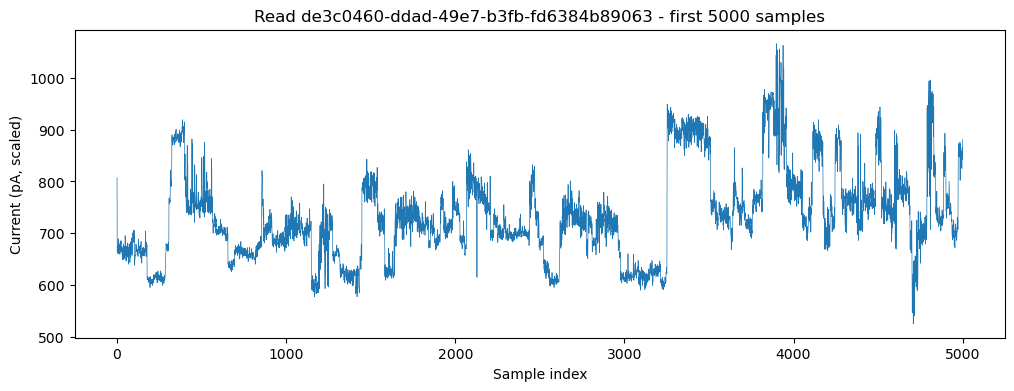

6269


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pod5 import Reader

# Load pod5 file
with Reader("m6A_DRACH.pod5") as reader:
    for read in reader.reads():
        signal = read.signal  # numpy array of int16
        read_id = read.read_id

        # Plot first 5000 points for clarity
        plt.figure(figsize=(12,4))
        plt.plot(signal[:5000], linewidth=0.5)
        plt.title(f"Read {read_id} - first 5000 samples")
        plt.xlabel("Sample index")
        plt.ylabel("Current (pA, scaled)")
        plt.show()
        print(len(signal))
        print(read)
        
        break  # remove this if you want to loop over all reads


In [11]:
from pod5 import Reader

with Reader("m6A_DRACH.pod5") as reader:
    print("Number of reads:", reader.num_reads)

Number of reads: 50000


In [21]:
from pod5 import Reader

with Reader("m6A_DRACH.pod5") as reader:
    print("Total reads:", reader.num_reads)

    for i, read in enumerate(reader.reads(), start=1):
        # Basic identifiers
        print(f"\nRead {i}/{reader.num_reads}")
        print("Read ID:", read.read_id)
        


        # Signal length
        print("Number of samples:", len(read.signal))

        # Timing info
        print("Start sample:", read.start_sample)
        print("Median before:", read.median_before)

        # Optional: get actual signal array
        signal = read.signal  # numpy array (int16)
        
        # break early if you don’t want to dump everything
        if i == 5:
            break


Total reads: 50000

Read 1/50000
Read ID: de3c0460-ddad-49e7-b3fb-fd6384b89063
Number of samples: 6269
Start sample: 92235428
Median before: 197.6719512939453

Read 2/50000
Read ID: c9c20793-f38d-441a-a4fa-197114d8595f
Number of samples: 5804
Start sample: 14106805
Median before: 196.45355224609375

Read 3/50000
Read ID: 4ef0e7f2-50cf-45fb-ab96-070dcb208f03
Number of samples: 11610
Start sample: 17782946
Median before: 194.96102905273438

Read 4/50000
Read ID: 66beedc1-d2a4-4f90-8064-0053b5ceba8f
Number of samples: 13286
Start sample: 17705470
Median before: 196.49185180664062

Read 5/50000
Read ID: c08e9cf2-a6b5-438d-bfa5-866c3a81b1e6
Number of samples: 5805
Start sample: 75751650
Median before: 202.8972625732422


In [30]:
from pod5 import Reader

with Reader("m6A_DRACH.pod5") as reader:
    read = next(reader.reads())

    print(read.run_info)

RunInfo(acquisition_id='68e2d378899aa9258a2afbd6859904096951d8a4', acquisition_start_time=datetime.datetime(2024, 4, 4, 15, 14, 50, 873000, tzinfo=<UTC>), adc_max=2047, adc_min=0, context_tags={'barcoding_enabled': '0', 'basecall_config_filename': 'rna_rp4_130bps_fast_prom.cfg', 'experiment_type': 'rna', 'local_basecalling': '1', 'package': 'bream4', 'package_version': '7.9.4', 'sample_frequency': '4000', 'selected_speed_bases_per_second': '130', 'sequencing_kit': 'sqk-rna004_rsr_30'}, experiment_name='', flow_cell_id='PAU65841', flow_cell_product_code='FLO-PRO004RA', protocol_name='user_scripts/RNA/RNA_RSR/sequencing_PRO004RA_RNA_RSR_30c_test:FLO-PRO004RA:SQK-RNA004_RSR_30:130', protocol_run_id='d34fb335-2f45-4b26-82cf-d1f02a54413e', protocol_start_time=datetime.datetime(2024, 4, 4, 15, 10, 39, 190000, tzinfo=<UTC>), sample_id='m6A_30C', sample_rate=4000, sequencing_kit='sqk-rna004_rsr_30', sequencer_position='1E', sequencer_position_type='promethion', software='python-pod5-converter'

In [25]:
from pod5 import Reader
import numpy as np

lengths = []
with Reader("m6A_DRACH.pod5") as reader:
    for read in reader.reads():
        lengths.append(len(read.signal))

lengths = np.array(lengths)
print("Number of reads:", len(lengths))
print("Average samples per read:", lengths.mean())
print("Average read duration (s):", lengths.mean() / 4000)

Number of reads: 50000
Average samples per read: 6661.16818


In [33]:
from pod5 import Reader

with Reader("m6A_DRACH.pod5") as reader:
    sample_rate = next(reader.reads()).run_info.sample_rate  # assume all reads have same rate

    start_samples = (read.start_sample for read in reader.reads())
    end_samples   = (read.start_sample + len(read.signal) for read in reader.reads())

    total_duration_seconds = (max(end_samples) - min(start_samples)) / sample_rate
    print("Estimated run length (s):", total_duration_seconds)
    print("Estimated run length (h):", total_duration_seconds / 3600)




<generator object <genexpr> at 0x7aaae44a73e0>
Estimated run length (s): 28079.0615
Estimated run length (h): 7.799739305555556


In [36]:
from pod5 import Reader

pod5_file = "m6A_DRACH.pod5"

with Reader(pod5_file) as reader:
    # get sample rate from first read
    sample_rate = next(reader.reads()).run_info.sample_rate

    total_samples = 0
    min_start = float("inf")
    max_end = 0

    for read in reader.reads():
        n = len(read.signal)
        start = read.start_sample
        end = start + n

        total_samples += n
        min_start = min(min_start, start)
        max_end = max(max_end, end)

# 1. Sum of all samples (total sequenced time)
total_sequenced_seconds = total_samples / sample_rate

# 2. Actual run duration (wall-clock time)
run_duration_seconds = (max_end - min_start) / sample_rate

print(f"Total sequenced time (s): {total_sequenced_seconds:.2f}")
print(f"Actual run duration (s): {run_duration_seconds:.2f}")



Total sequenced time (s): 83264.60
Actual run duration (s): 28079.06


Read 1/50000
Read ID: de3c0460-ddad-49e7-b3fb-fd6384b89063
Number of samples: 6269
Read 2/50000
Read ID: c9c20793-f38d-441a-a4fa-197114d8595f
Number of samples: 5804
Read 3/50000
Read ID: 4ef0e7f2-50cf-45fb-ab96-070dcb208f03
Number of samples: 11610
Read 4/50000
Read ID: 66beedc1-d2a4-4f90-8064-0053b5ceba8f
Number of samples: 13286
Read 5/50000
Read ID: c08e9cf2-a6b5-438d-bfa5-866c3a81b1e6
Number of samples: 5805


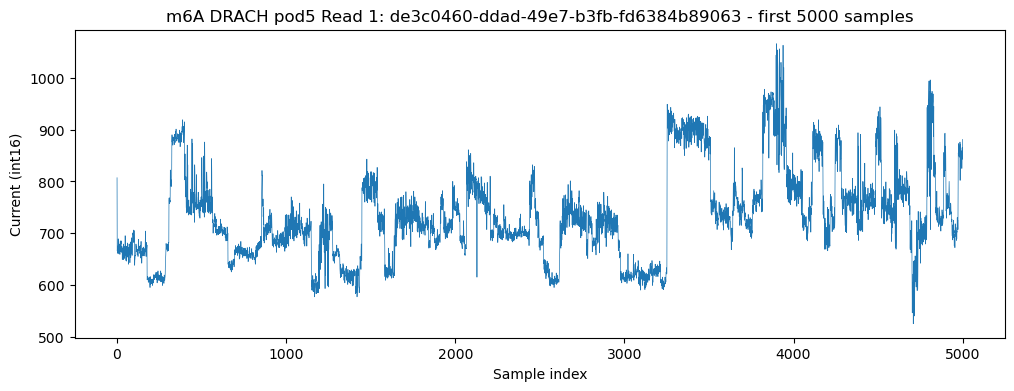

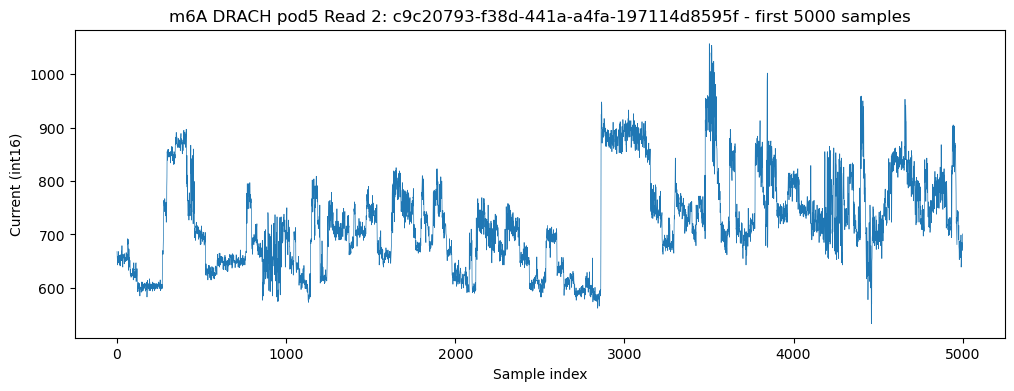

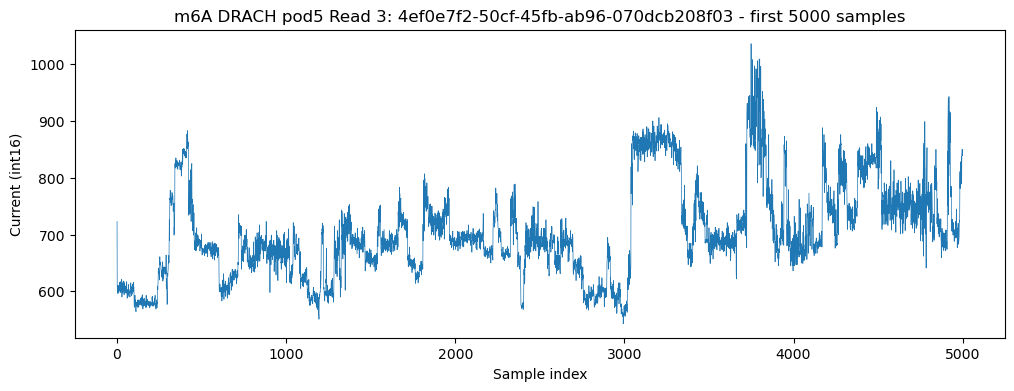

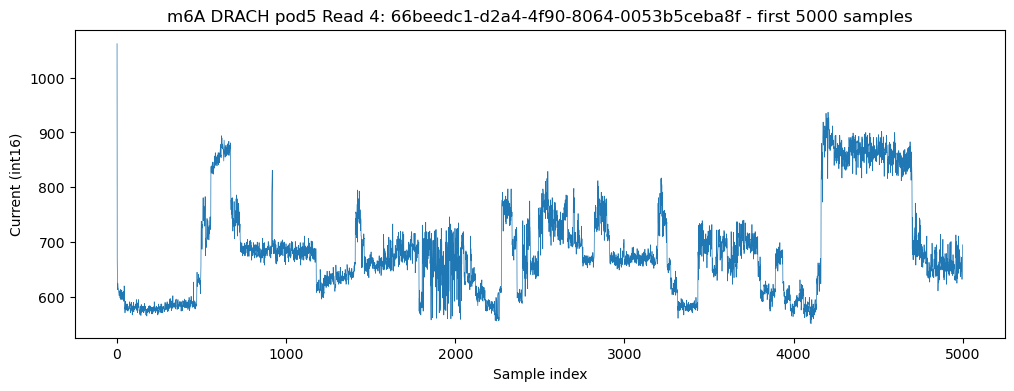

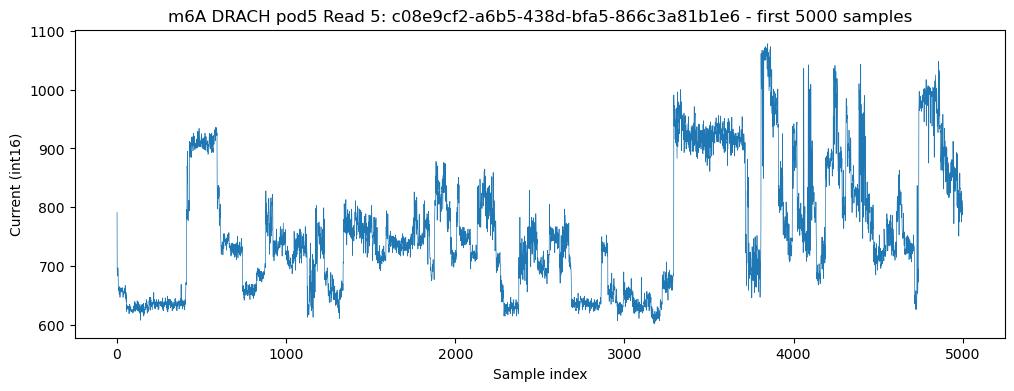

In [41]:
import matplotlib.pyplot as plt
from pod5 import Reader

pod5_file = "m6A_DRACH.pod5"

with Reader(pod5_file) as reader:
    for i, read in enumerate(reader.reads(), start=1):
        signal = read.signal  # raw signal as numpy array
        read_id = read.read_id

        # Plot the first 5000 samples for clarity (or full signal if short)
        plt.figure(figsize=(12,4))
        plt.plot(signal[:5000], linewidth=0.5)
        plt.title(f"m6A DRACH pod5 Read {i}: {read_id} - first 5000 samples")
        plt.xlabel("Sample index")
        plt.ylabel("Current (int16)")
        plt.savefig(f"read_{i}_{read_id}.png")
        
        print(f"Read {i}/{reader.num_reads}")
        print(f"Read ID: {read_id}")
        print(f"Number of samples: {len(signal)}")
        
        # Stop after 5 reads for testing, remove to iterate over all
        if i == 5:
            break
